# Basic GIS Functionalities Python

## Libraries and settings

In [1]:
# Libraries
import os
import folium
import geopandas as gpd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Show current working directory
print(os.getcwd())

/workspaces/spatial_data_analysis/01_Python_Basic_GIS_Functionalities


## Read spatial data

In [2]:
polys = gpd.read_file("GEN_A4_GEMEINDEN_2019_epsg4326.json")        #Polygonkarte aus JSON-Datei einlesen

print("nrows, ncols", polys.shape)                                  #Anzahl Zeilen und Spalten ausgeben
print("-------------------------------------------------------")    #Trennlinie ausgeben
print("Type:", type(polys))                                         #Datentyp des Objekts ausgeben

polys                                                               #GeoDataFrame mit Polygon-Geometrien anzeigen

nrows, ncols (162, 6)
-------------------------------------------------------
Type: <class 'geopandas.geodataframe.GeoDataFrame'>


,BFS,NAME,BEZIRKSNAM,ART_TEXT,ART_CODE,geometry
0,117,Hinwil,Hinwil,Gemeinde,1,"POLYGON ((8.84778 47.3241, 8.85861 47.32162, 8..."
1,131,Adliswil,Horgen,Gemeinde,1,"POLYGON ((8.53489 47.32502, 8.53662 47.321, 8...."
2,3,Bonstetten,Affoltern,Gemeinde,1,"POLYGON ((8.46026 47.33326, 8.46753 47.3341, 8..."
3,154,Küsnacht (ZH),Meilen,Gemeinde,1,"POLYGON ((8.60977 47.33352, 8.61127 47.32749, ..."
4,135,Kilchberg (ZH),Horgen,Gemeinde,1,"POLYGON ((8.54625 47.33441, 8.54875 47.33113, ..."
...,...,...,...,...,...,...
157,192,Egg,Uster,Gemeinde,1,"POLYGON ((8.70571 47.32027, 8.70343 47.31724, ..."
158,115,Gossau (ZH),Hinwil,Gemeinde,1,"POLYGON ((8.77442 47.31964, 8.78551 47.31752, ..."
159,29,Flurlingen,Andelfingen,Gemeinde,1,"POLYGON ((8.63514 47.69119, 8.64204 47.69104, ..."
160,27,Feuerthalen,Andelfingen,Gemeinde,1,"POLYGON ((8.64708 47.69551, 8.65089 47.6938, 8..."


## Plot spatial map

In [3]:
m = folium.Map(location=[47.44, 8.65], zoom_start=10)  #Karte mit Startposition und Zoomstufe initialisieren

folium.Choropleth(                                     #Choroplethenkarte auf Basis der Polygon-Daten erstellen
    geo_data=polys,                                    #GeoDataFrame mit den Polygon-Geometrien verwenden
    name='polys',                                      #Name des Karten-Layers festlegen
    fill_color='greenyellow'                           #Füllfarbe der Polygone festlegen
).add_to(m)                                            #Layer zur Karte hinzufügen

folium.LayerControl().add_to(m)                        #Layer-Steuerung zur Karte hinzufügen

m                                                      #Karte anzeigen

## Plot a subset of the spatial map

In [4]:
idx = polys[polys['NAME'] == 'Winterthur'].index[0]  #Index der Gemeinde Winterthur ermitteln

polys.iloc[[idx]]                                    #Zeile von Winterthur anhand des Index auswählen und anzeigen

,BFS,NAME,BEZIRKSNAM,ART_TEXT,ART_CODE,geometry
119,230,Winterthur,Winterthur,Gemeinde,1,"POLYGON ((8.76757 47.54828, 8.77696 47.5472, 8..."


In [5]:
m = folium.Map(location=[47.44, 8.65], zoom_start=10)   #Karte mit Startposition und Zoomstufe initialisieren

folium.Choropleth(                                      #Choroplethenkarte für die ausgewählte Gemeinde erstellen
    geo_data=polys.iloc[[idx]],                         #Nur das Polygon von Winterthur verwenden
    name='polys',                                       #Name des Karten-Layers festlegen
    fill_color='greenyellow'                            #Füllfarbe des Polygons festlegen
).add_to(m)                                             #Layer zur Karte hinzufügen

folium.LayerControl().add_to(m)                         #Layer-Steuerung zur Karte hinzufügen

m                                                       #Karte anzeigen

## Read attribute data

In [ ]:
data = pd.read_excel('municipalities_kt_zh_data.xlsx', index_col=None)  #Gemeindedaten aus Excel-Datei einlesen
print(type(data))                                                       #Datentyp des eingelesenen Objekts ausgeben
data.head(5)                                                            #Erste 5 Zeilen des DataFrames anzeigen

<class 'pandas.DataFrame'>


,BFS,municipality_name,residents,percentage_foreigners,area_km2,residents_per_km2
0,21,Adlikon,665,9.2,6.58,101.063830
1,131,Adliswil,18803,35.3,7.77,2419.948520
2,241,Aesch (ZH),1348,15.7,5.24,257.251908
3,1,Aeugst am Albis,1941,12.7,7.91,245.385588
4,2,Affoltern am Albis,12146,27.6,10.59,1146.931067


## Explore attribute data

In [7]:
data.describe()  #Statistische Kennzahlen der numerischen Spalten anzeigen

,BFS,residents,percentage_foreigners,area_km2,residents_per_km2
count,162.000000,162.000000,162.000000,162.000000,162.000000
mean,124.969136,9269.549383,18.917284,10.251914,795.841253
std,83.345157,33263.791485,8.242690,10.075273,801.817314
min,1.000000,342.000000,5.100000,1.590000,64.950712
25%,56.250000,1892.750000,12.500000,5.060000,231.625802
50%,112.500000,4396.000000,18.300000,7.885000,552.378602
75%,195.750000,7837.750000,24.450000,12.012500,1014.056106
max,298.000000,409241.000000,46.200000,87.930000,4654.168088


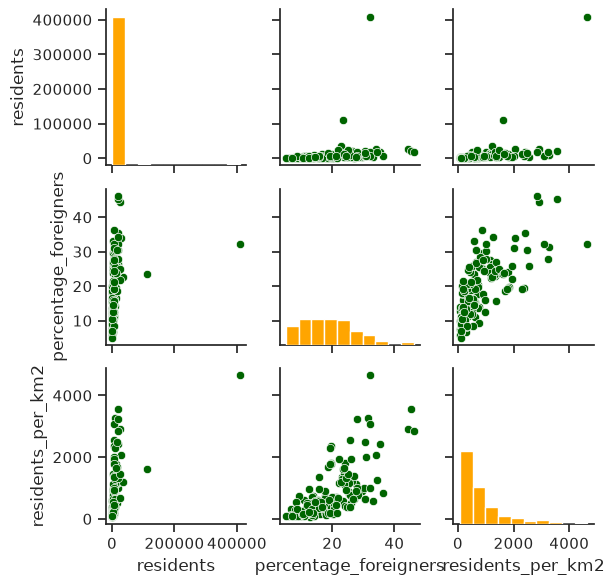

In [8]:
sns.set_theme(style="ticks")                                                                               #Seaborn-Darstellungsstil festlegen
g = sns.PairGrid(data[['residents', 'percentage_foreigners', 'residents_per_km2']], height=2.0, aspect=1)  #PairGrid für die drei ausgewählten Variablen erstellen
g.map_upper(sns.scatterplot, color='darkgreen')                                                             #Scatterplots im oberen Bereich darstellen
g.map_lower(sns.scatterplot, color='darkgreen')                                                             #Scatterplots im unteren Bereich darstellen
g.map_diag(plt.hist, color='orange')                                                                        #Histogramme der einzelnen Variablen auf der Diagonale darstellen
plt.show()                                                                                                  #Pairplot anzeigen

## Find a useful base map

In [9]:
m = folium.Map(location=[47.364, 8.535],    #Karte mit Startkoordinaten initialisieren
              tiles='EsriWorldImagery')     #Esri-Satellitenkarte als Basiskarte verwenden

# Alternative Kartenstile:
# EsriWorldImagery                          #Satelliten-/Luftbildkarte
# EsriWorldTopoMap                          #Topografische Karte
# EsriWorldGrayCanvas                       #Graue, reduzierte Basiskarte
# CartoDBDarkMatter                         #Dunkler Kartenstil
# CartoDBPositron                           #Heller, minimalistischer Kartenstil

m                                           #Karte anzeigen

## Create choropleth map

In [ ]:
def folium_del_legend(choropleth: folium.Choropleth):  #Funktion zum Entfernen der ursprünglichen Legende definieren
    del_list = []                                      #Leere Liste für zu löschende Elemente erstellen
    for child in choropleth._children:                 #Alle untergeordneten Elemente des Choropleth-Layers durchlaufen
        if child.startswith('color_map'):              #Prüfen, ob das Element zur Farblegende gehört
            del_list.append(child)                     #Element zur Löschliste hinzufügen
            for del_item in del_list:                  #Alle Elemente der Löschliste durchlaufen
                choropleth._children.pop(del_item)     #Legenden-Element aus dem Choropleth-Layer entfernen
                return choropleth                      #Choropleth-Layer ohne Legende zurückgeben


polys = 'GEN_A4_GEMEINDEN_2019_epsg4326.json'           #GeoJSON-Datei mit Gemeindegrenzen festlegen
data = pd.read_excel('municipalities_kt_zh_data.xlsx')  #Gemeindedaten aus Excel-Datei einlesen


bins = list(data['residents_per_km2'].quantile([0.00, 0.25, 0.50, 0.75, 1.00]))  #Klassengrenzen anhand der Quartile der Bevölkerungsdichte erstellen


m = folium.Map(location=[47.44, 8.65],                  #Karte auf den Kanton Zürich zentrieren
               zoom_start=10,                           #Anfangs-Zoomstufe festlegen
               tiles='CartoDBPositron')                 #Hellen Kartenstil als Basiskarte verwenden


folium.Choropleth(                                      #Choroplethenkarte erstellen
        geo_data=polys,                                 #GeoJSON-Datei mit den Gemeindegrenzen verwenden
        name='choropleth',                              #Namen des Karten-Layers festlegen
        data=data,                                      #Gemeindedaten für die Visualisierung verwenden
        columns=['BFS', 'residents_per_km2'],           #BFS-Nummer und Bevölkerungsdichte auswählen
        key_on='feature.properties.BFS',                #BFS-Nummer zur Verknüpfung von Karte und Daten verwenden
        fill_color='RdGy',                              #Farbskala Rot-Grau festlegen
        fill_opacity=0.7,                               #Transparenz der Flächen festlegen
        line_opacity=0.5,                               #Transparenz der Gemeindegrenzen festlegen
        legend_name='Number of residents',              #Titel der Kartenlegende festlegen
        bins=bins,                                      #Zuvor berechnete Klassengrenzen verwenden
        reset=True                                      #Farbskala nach den definierten Klassen zurücksetzen
).add_to(m)                                             #Choropleth-Layer zur Karte hinzufügen


folium.LayerControl(collapsed=True).add_to(m)           #Einklappbare Layer-Steuerung hinzufügen


m                                                       #Karte anzeigen


# m.save('map.html')  # Karte optional als HTML-Datei speichern

### Jupyter notebook --footer info-- (please always provide this at the end of each notebook)

In [ ]:
import os
import platform
import socket
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')